<h1 style="color:#1F4E79; text-align:center;">
Vendor Performance Data Analytics
</h1>

<h2 style="color:#C00000; text-align:center;">
Exploratory Data Analysis Report
</h2>

<p style="color:#1F4E79; font-size:16px;">
<b>Tools Used:</b> Python, Pandas, MySQL, Power BI
</p>

<p style="color:#C00000; font-size:16px;">
<b>Project Objective:</b>
</p>

<p style="color:#333333; font-size:14px;">
To analyze vendor sales and purchase performance, identify
high-performing and low-performing vendors, evaluate profitability,
inventory turnover, and derive actionable business insights.
</p>

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from scipy.stats import ttest_ind
import scipy.stats as stats

warnings.filterwarnings('ignore')

In [167]:
connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password="Password@123",
    host="localhost",
    port=3306,
    database="vendor_performance"
)

engine = create_engine(connection_url)
conn = engine.connect()

In [168]:
df = pd.read_sql("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,115609.0,2680972.71,160247.0,4.819073e+06,561512.37,294438.66,144929.24,2.138101e+06,44.367466,1.386112,1.797509
1,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,101636.0,2669977.72,142049.0,5.101920e+06,672819.31,260999.20,68601.68,2.431942e+06,47.667192,1.397625,1.910847
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,136129.0,2482992.96,187140.0,4.538121e+06,461140.15,343854.07,123780.22,2.055128e+06,45.285875,1.374725,1.827682
3,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,95215.0,2084256.35,135838.0,4.223108e+06,545778.28,249587.83,257032.07,2.138851e+06,50.646383,1.426645,2.026194
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,119516.0,1932573.72,200412.0,4.475973e+06,420050.01,368242.80,257032.07,2.543399e+06,56.823382,1.676863,2.316068


<h1 style="color:#1F4E79; font-size:42px; font-weight:bold;">
Exploratory Data Analysis Insights
</h1>

<h2 style="color:#C00000; font-size:32px; font-weight:bold;">
Summary Statistics
</h2>

In [169]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,9896.0,10411.962308,18204.279316,2.000000,3664.000000,7153.000000,9552.000000,1.733570e+05
Brand,9896.0,17959.993129,12729.697465,58.000000,5795.750000,18451.000000,25217.000000,9.063100e+04
PurchasePrice,9896.0,22.879706,106.725152,0.360000,6.770000,10.250000,18.250000,5.681810e+03
ActualPrice,9896.0,33.605657,145.215352,0.490000,10.490000,15.990000,26.990000,7.499990e+03
Volume,9896.0,851.238329,652.989043,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,9896.0,2325.418452,7941.951923,1.000000,26.000000,228.000000,1493.750000,2.339740e+05
TotalPurchaseDollars,9896.0,21974.575547,87007.479970,0.710000,359.640000,3010.530000,16189.427500,2.680973e+06
TotalSalesQuantity,9896.0,3305.708064,11348.954981,0.000000,43.000000,336.500000,2192.250000,3.349390e+05
TotalSalesDollars,9896.0,45399.105508,173859.235113,0.000000,943.610000,6478.955000,32172.462500,5.101920e+06
TotalSalesPrice,9896.0,20195.089579,46433.182042,0.000000,369.412500,3554.175000,18277.127500,6.728193e+05


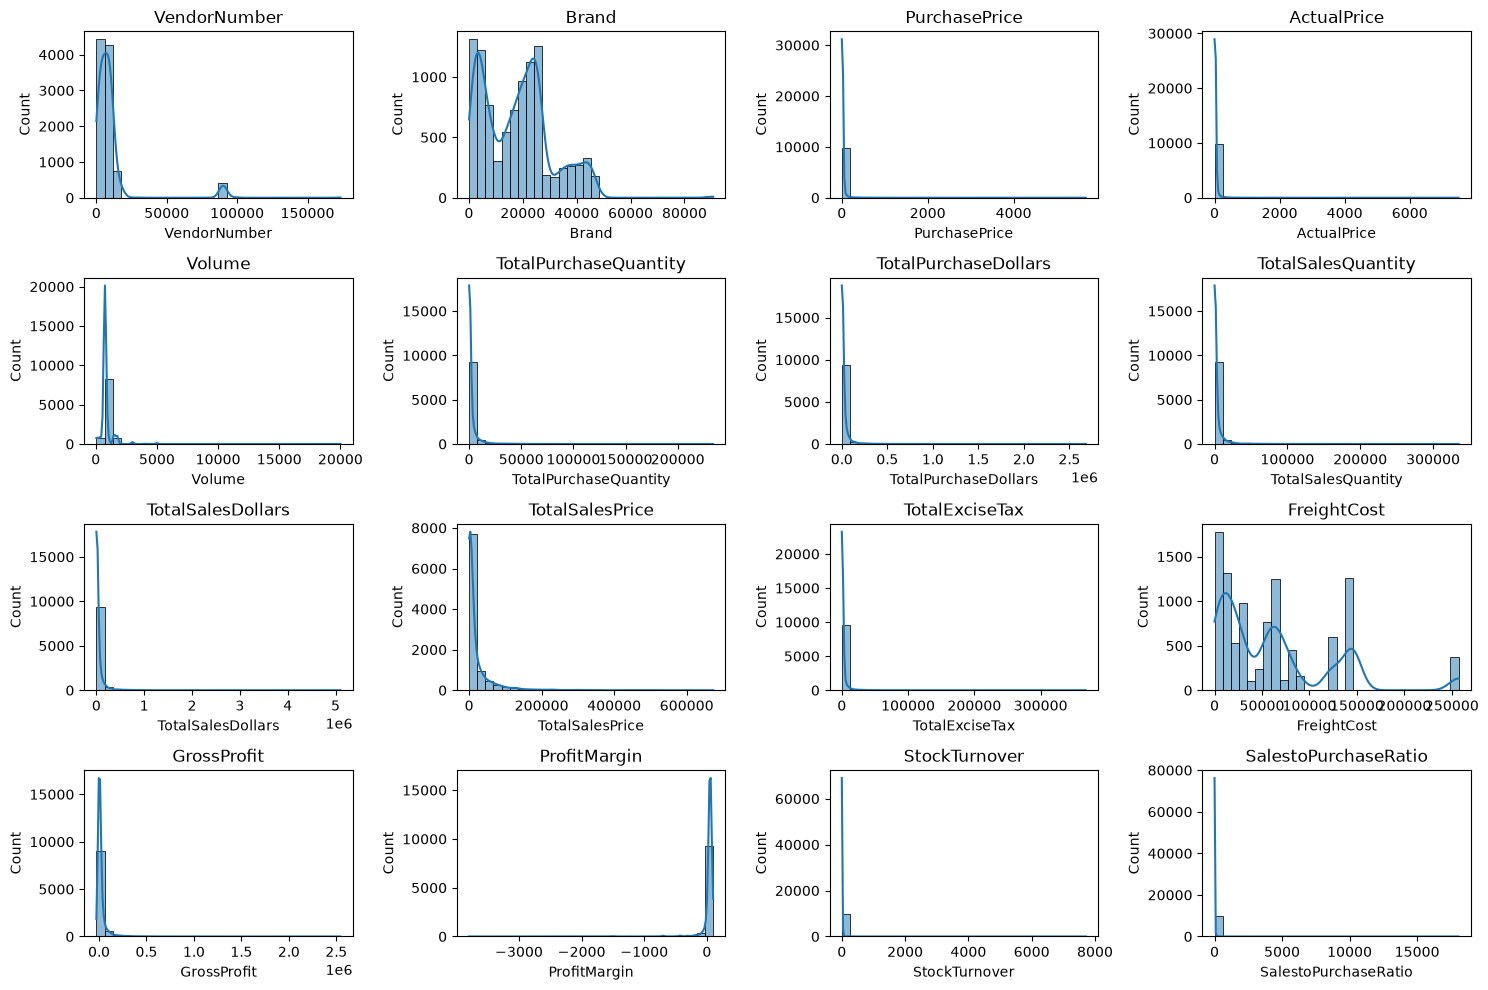

In [170]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

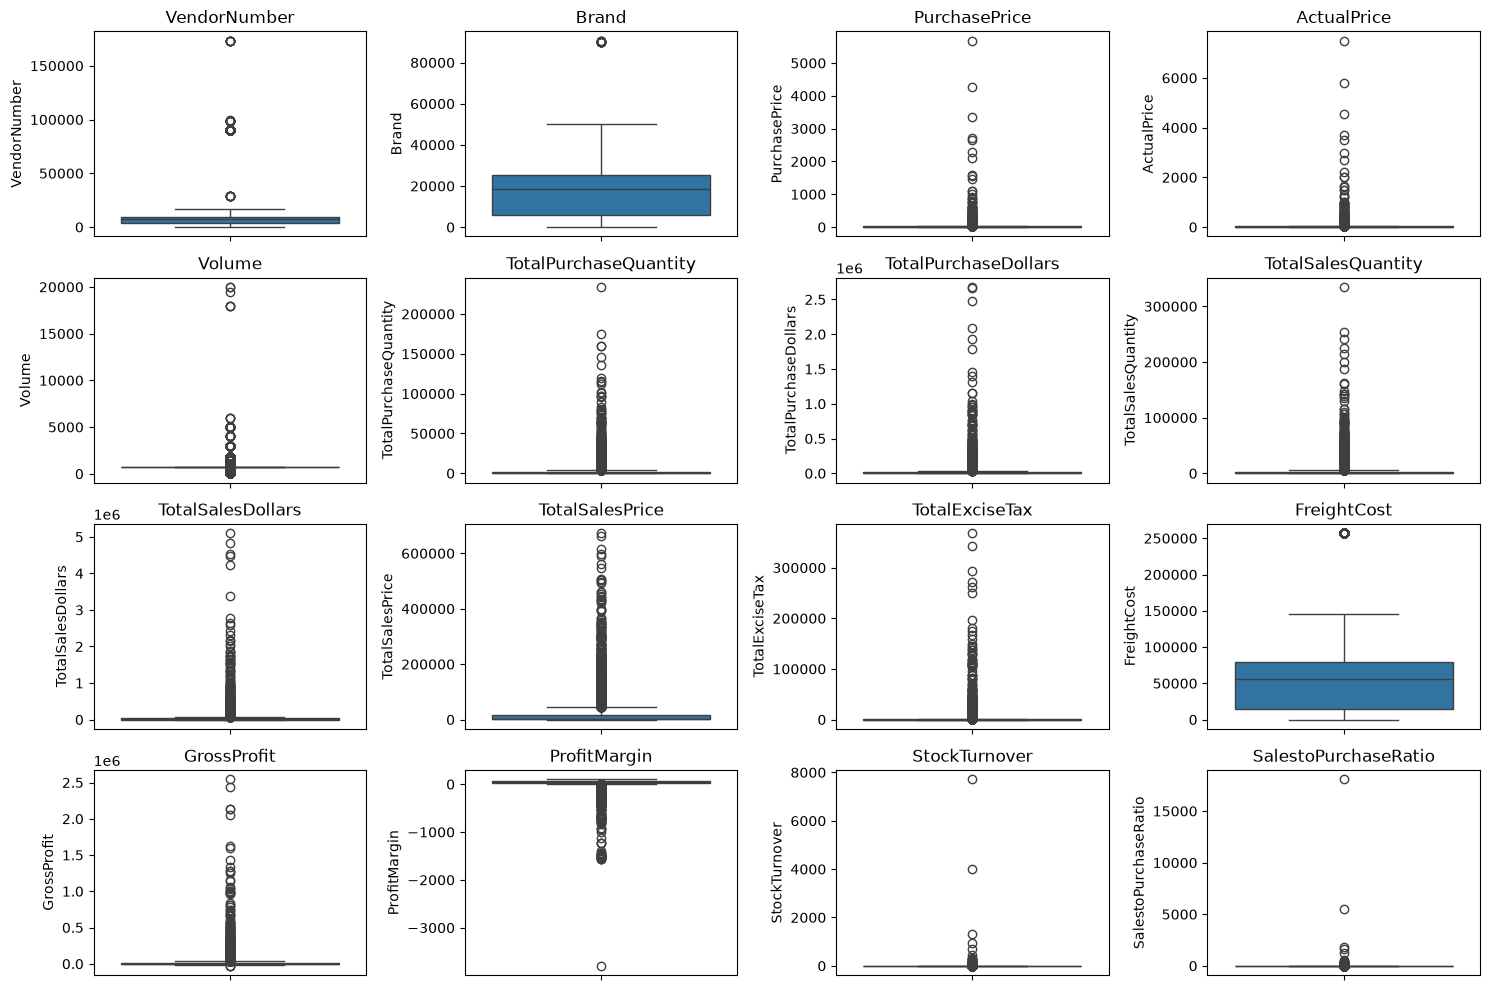

In [171]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [172]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)


In [173]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,115609.0,2680972.71,160247.0,4.819073e+06,561512.37,294438.66,144929.24,2.138101e+06,44.367466,1.386112,1.797509
1,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,101636.0,2669977.72,142049.0,5.101920e+06,672819.31,260999.20,68601.68,2.431942e+06,47.667192,1.397625,1.910847
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,136129.0,2482992.96,187140.0,4.538121e+06,461140.15,343854.07,123780.22,2.055128e+06,45.285875,1.374725,1.827682
3,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,95215.0,2084256.35,135838.0,4.223108e+06,545778.28,249587.83,257032.07,2.138851e+06,50.646383,1.426645,2.026194
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,119516.0,1932573.72,200412.0,4.475973e+06,420050.01,368242.80,257032.07,2.543399e+06,56.823382,1.676863,2.316068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8905,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2.0,2.84,14.0,2.786000e+01,5.97,0.73,257032.07,2.502000e+01,89.806174,7.000000,9.809859
8906,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2.0,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,1.331000e+01,83.448276,2.500000,6.041667
8907,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6.0,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,6.332000e+01,96.436186,22.333333,28.059829
8908,3960,DIAGEO NORTH AMERICA INC,3775,Smirnoff Sorbet Pine/Coconut,0.73,0.99,50.0,1.0,0.73,120.0,1.188000e+02,46.53,6.20,257032.07,1.180700e+02,99.385522,120.000000,162.739726


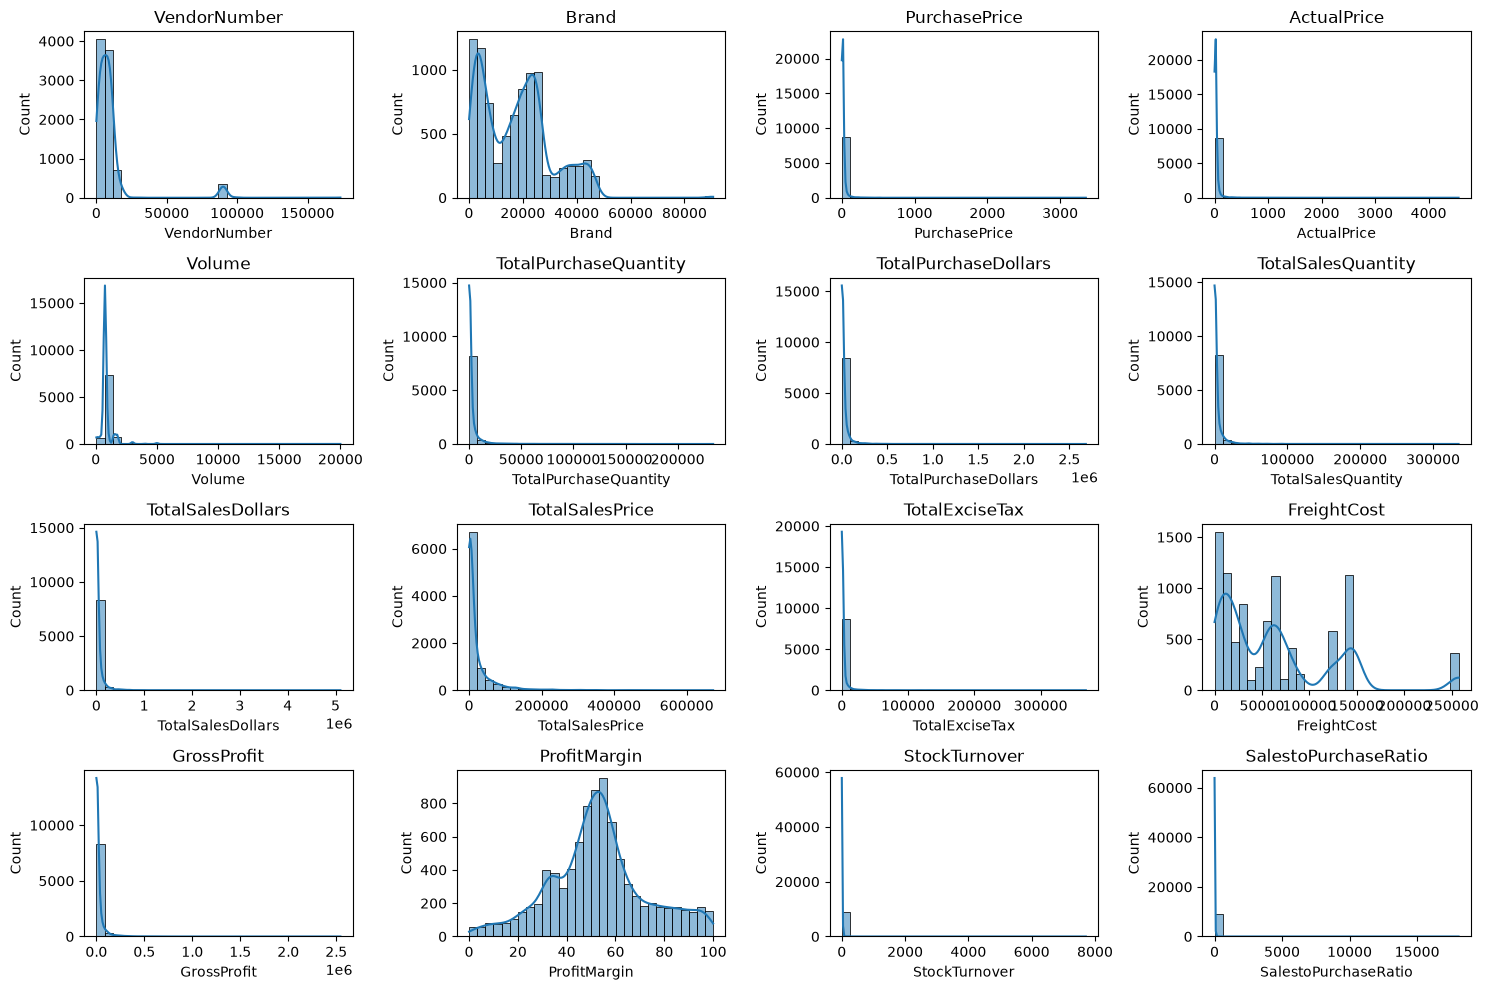

In [174]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

<h3 style="
    color:#000000;
    font-size:24px;
    font-weight:700;
    margin-bottom:15px;
">
Negative &amp; Zero Values:
</h3>

<p style="font-size:18px; line-height:1.6; color:#222222;">
<b>Gross Profit:</b>
Minimum of -52,002.78, indicating potential losses due to high costs
or heavy discounts. This could be due to selling products at lower
prices than their purchase costs.
</p>

<p style="font-size:18px; line-height:1.6; color:#222222;">
<b>Profit Margin:</b>
Has a minimum of -∞, which suggests instances where revenue is zero
or even lower than the total cost, leading to extreme negative profit
margins.
</p>

<p style="font-size:18px; line-height:1.6; color:#222222;">
<b>Total Sales Quantity &amp; Sales Dollars:</b>
Some products show zero sales, indicating they were purchased but
never sold. These may be slow-moving or obsolete stock, leading to
inventory inefficiencies.
</p>

<h3 style="
    color:#000000;
    font-size:24px;
    font-weight:700;
    margin-top:25px;
    margin-bottom:15px;
">
Outliers Detected by High Standard Deviations:
</h3>

<p style="font-size:18px; line-height:1.6; color:#222222;">
<b>Purchase &amp; Actual Prices:</b>
The maximum values (5,681.81 &amp; 7,499.99) are significantly
higher than the mean (24.39 &amp; 35.64),indicating premium product
offerings.
</p>


<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
<b>Freight Cost:</b>
Extreme variation from 0.09 to 257,032.07 suggests logistics
inefficiencies, bulk shipments, or erratic shipping costs across
different products.
</p>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
<b>Stock Turnover:</b>
Ranges from 0 to 274.5, suggesting some products sell rapidly while
others remain unsold for long periods. A value greater than 1
indicates that sales for a product exceed the purchased quantity due
to older stock fulfilling orders.
</p>


<h2 style="
    color:#C00000;
    font-size:30px;
    font-weight:700;
    margin-bottom:18px;
">
Data Filtering
</h2>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
">
To enhance the reliability of the insights, we removed inconsistent
data points where:
</p>

<ul style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
">

<li>
<b>Gross Profit ≤ 0</b>
(to exclude transactions leading to losses).
</li>

<li>
<b>Profit Margin ≤ 0</b>
(to ensure analysis focuses on profitable transactions).
</li>

<li>
<b>Total Sales Quantity = 0</b>
(to eliminate inventory that was never sold).
</li>

</ul>

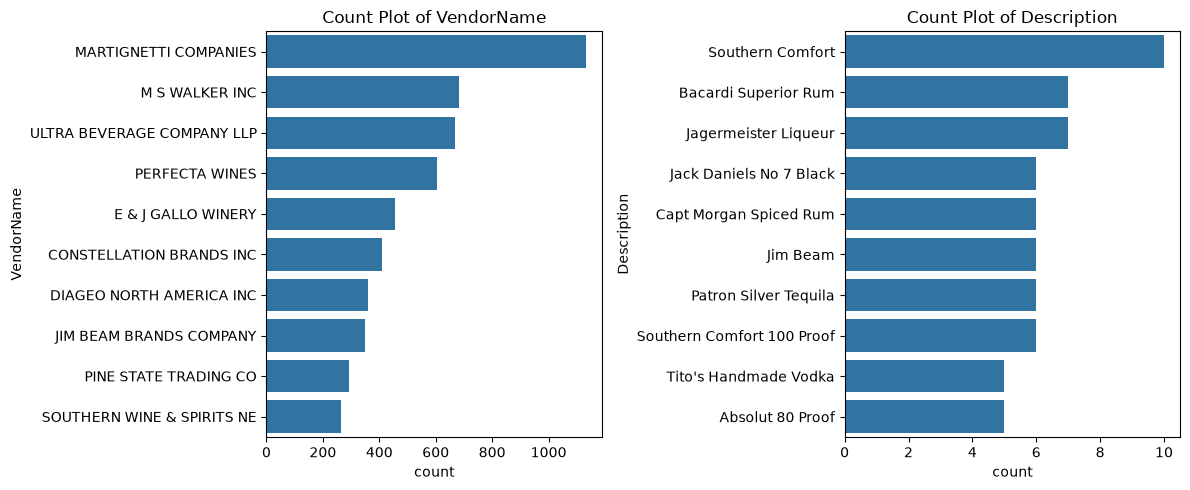

In [175]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

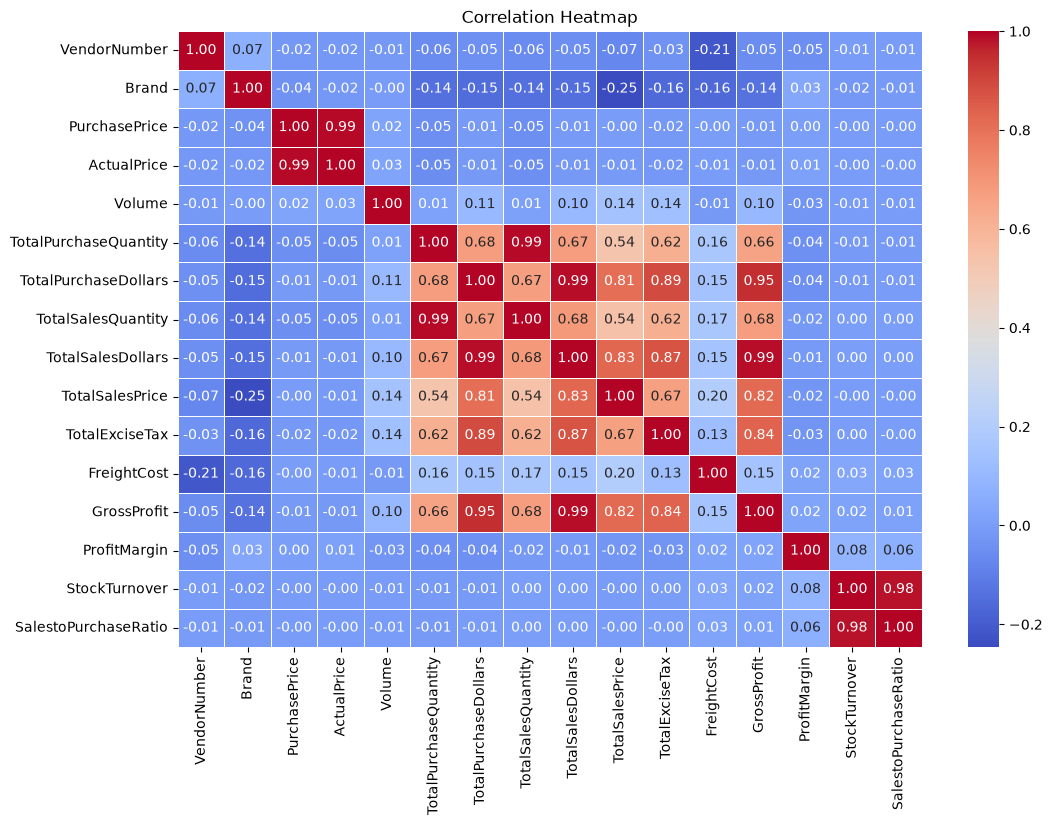

In [176]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
<b>Purchase Price vs. Total Sales Dollars &amp; Gross Profit:</b>
Weak correlation (-0.012 and -0.016), indicating that price variations
do not significantly impact sales revenue or profit.
</p>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
<b>Total Purchase Quantity vs. Total Sales Quantity:</b>
Strong correlation (0.999), confirming efficient inventory turnover.
</p>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
<b>Profit Margin vs. Total Sales Price:</b>
Negative correlation (-0.179), suggesting increasing sales prices may
lead to reduced margins, possibly due to competitive pricing pressures.
</p>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
<b>Stock Turnover vs. Gross Profit &amp; Profit Margin:</b>
Weak negative correlation (-0.038 &amp; -0.055), indicating that faster
stock turnover does not necessarily equate to higher profitability.
</p>

In [177]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [178]:
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,37.450887
1,.nparalleled Svgn Blanc,1094.63,88.248084
2,10 Span Cab Svgn CC,2703.89,47.169448
3,10 Span Chard CC,3325.56,50.019846
4,10 Span Pnt Gris Monterey Cy,2082.22,49.169636
...,...,...,...
7987,Zorvino Vyds Peachez,15494.49,50.481881
7988,Zorvino Vyds Pearz,20629.35,53.504352
7989,Zorvino Vyds Sangiovese,10579.03,59.239174
7990,Zum Rsl,10857.34,50.323928


In [179]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [180]:
low_sales_threshold

np.float64(593.7885)

In [182]:
high_margin_threshold

np.float64(74.4383694043932)

<h2 style="
    color:#C00000;
    font-size:30px;
    font-weight:700;
    margin-bottom:22px;
">
Research Questions &amp; Key Findings
</h2>

<h3 style="
    color:#111111;
    font-size:24px;
    font-weight:700;
    margin-bottom:15px;
">
1. Brands for Promotional or Pricing Adjustments
</h3>

In [183]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
2150,Concannon Glen Ellen Wh Zin,15.95,83.448276
2268,Crown Royal Apple,27.86,89.806174
6469,Sauza Sprklg Wild Berry Marg,27.96,82.153076
7461,Tracia Syrah,44.94,88.495772
622,Basilica Amaretto,47.45,85.079031
...,...,...,...
7887,Wyborowa Vodka,579.74,85.935074
1400,Casa Liliana Good Chard,582.47,95.364568
2843,Ermita Sn Felices Rose Rioja,586.63,90.109609
2319,Cupcake Chianti,587.16,92.216772


In [184]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] < 10000] #for better visualization

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
<b>171 brands</b> exhibit lower sales but higher profit margins,
which could benefit from targeted marketing, promotions, or price
optimizations to increase volume without compromising profitability.
</p>

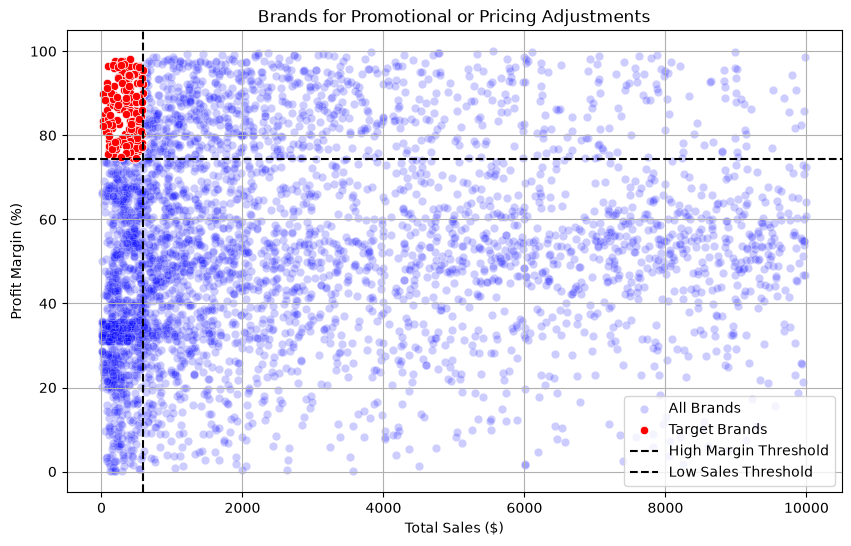

In [185]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

In [186]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      6.818075e+07
MARTIGNETTI COMPANIES         4.019475e+07
PERNOD RICARD USA             3.216785e+07
JIM BEAM BRANDS COMPANY       3.174307e+07
BACARDI USA INC               2.498186e+07
CONSTELLATION BRANDS INC      2.443571e+07
E & J GALLO WINERY            1.846738e+07
BROWN-FORMAN CORP             1.835036e+07
ULTRA BEVERAGE COMPANY LLP    1.722308e+07
M S WALKER INC                1.512907e+07
Name: TotalSalesDollars, dtype: float64

In [187]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [188]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [189]:
top_vendors.apply(lambda x:format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      68.18M
MARTIGNETTI COMPANIES         40.19M
PERNOD RICARD USA             32.17M
JIM BEAM BRANDS COMPANY       31.74M
BACARDI USA INC               24.98M
CONSTELLATION BRANDS INC      24.44M
E & J GALLO WINERY            18.47M
BROWN-FORMAN CORP             18.35M
ULTRA BEVERAGE COMPANY LLP    17.22M
M S WALKER INC                15.13M
Name: TotalSalesDollars, dtype: str

In [190]:
top_brands.apply(lambda x:format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

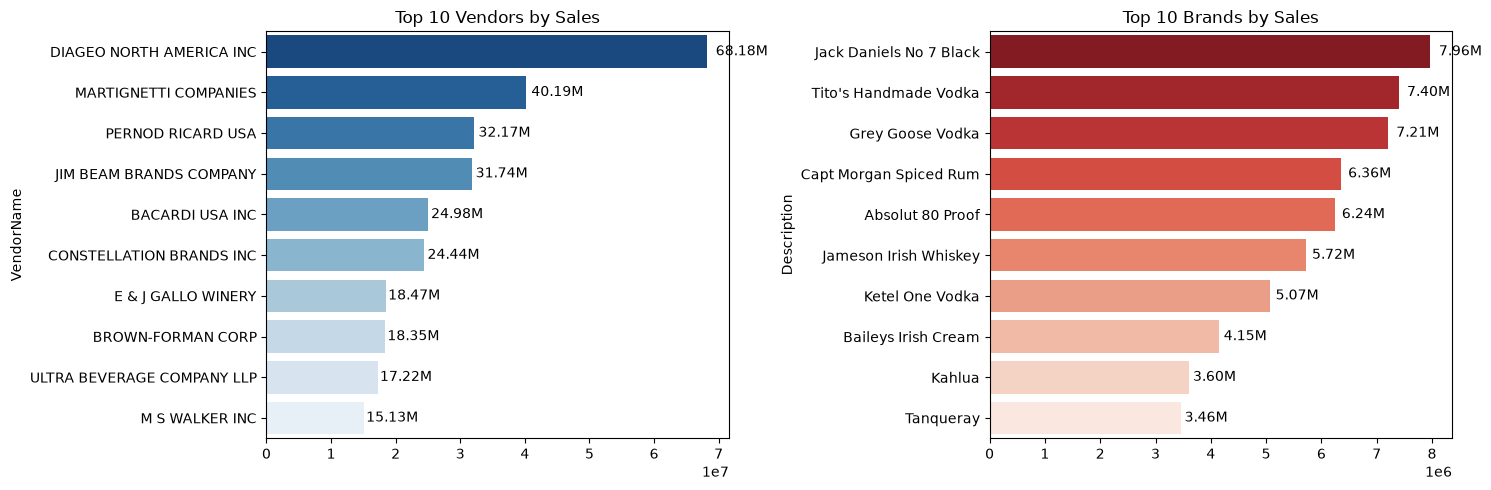

In [191]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [192]:
vendor_Performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars' : 'sum',
    'GrossProfit' : 'sum',
    'TotalSalesDollars' : 'sum'
}).reset_index()

In [193]:
vendor_Performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,39071.39,28504.83,67576.22
1,ALISA CARR BEVERAGES,21800.82,82670.12,104470.94
2,ALTAMAR BRANDS LLC,8352.80,7354.01,15706.81
3,AMERICAN SPIRITS EXCHANGE,998.04,721.93,1719.97
4,AMERICAN VINTAGE BEVERAGE,119491.93,70642.70,190134.63
...,...,...,...,...
114,WEIN BAUER INC,26042.12,30888.11,56930.23
115,WESTERN SPIRITS BEVERAGE CO,224432.34,218637.86,443070.20
116,WILLIAM GRANT & SONS INC,3814818.72,3772868.04,7587686.76
117,WINE GROUP INC,3647450.98,4674842.07,8322293.05


In [194]:
vendor_Performance['PurchaseContribution%'] = (vendor_Performance['TotalPurchaseDollars'] / vendor_Performance['TotalPurchaseDollars'].sum()) * 100

In [195]:
vendor_Performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ADAMBA IMPORTS INTL INC,39071.39,28504.83,67576.22,0.018252
1,ALISA CARR BEVERAGES,21800.82,82670.12,104470.94,0.010184
2,ALTAMAR BRANDS LLC,8352.80,7354.01,15706.81,0.003902
3,AMERICAN SPIRITS EXCHANGE,998.04,721.93,1719.97,0.000466
4,AMERICAN VINTAGE BEVERAGE,119491.93,70642.70,190134.63,0.055819
...,...,...,...,...,...
114,WEIN BAUER INC,26042.12,30888.11,56930.23,0.012165
115,WESTERN SPIRITS BEVERAGE CO,224432.34,218637.86,443070.20,0.104840
116,WILLIAM GRANT & SONS INC,3814818.72,3772868.04,7587686.76,1.782028
117,WINE GROUP INC,3647450.98,4674842.07,8322293.05,1.703845


In [196]:
vendor_Performance = round(vendor_Performance.sort_values('PurchaseContribution%',ascending = False),2)

In [197]:
# Display Top 10 Vendors
top_vendors = vendor_Performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,33.37M,34.81M,68.18M,15.59
57,MARTIGNETTI COMPANIES,18.09M,22.10M,40.19M,8.45
46,JIM BEAM BRANDS COMPANY,16.77M,14.98M,31.74M,7.83
68,PERNOD RICARD USA,15.87M,16.30M,32.17M,7.41
6,BACARDI USA INC,12.21M,12.77M,24.98M,5.70
20,CONSTELLATION BRANDS INC,10.59M,13.84M,24.44M,4.95
11,BROWN-FORMAN CORP,9.16M,9.19M,18.35M,4.28
107,ULTRA BEVERAGE COMPANY LLP,8.45M,8.77M,17.22M,3.95
30,E & J GALLO WINERY,8.23M,10.24M,18.47M,3.84
53,M S WALKER INC,7.10M,8.03M,15.13M,3.32


In [198]:
vendor_Performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,33374649.23,34806104.29,68180753.52,15.59
57,MARTIGNETTI COMPANIES,18093333.49,22101412.29,40194745.78,8.45
46,JIM BEAM BRANDS COMPANY,16765692.31,14977374.52,31743066.83,7.83
68,PERNOD RICARD USA,15872387.24,16295461.22,32167848.46,7.41
6,BACARDI USA INC,12211006.95,12770853.70,24981860.65,5.70
...,...,...,...,...,...
41,HIGHLAND WINE MERCHANTS LLC,667.92,326.55,994.47,0.00
44,"IRA GOLDMAN AND WILLIAMS, LLP",167.02,498.80,665.82,0.00
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
33,FANTASY FINE WINES CORP,64.32,263.27,327.59,0.00


In [199]:
top_vendors['PurchaseContribution%'].sum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,33.37M,34.81M,68.18M,15.59
57,MARTIGNETTI COMPANIES,18.09M,22.10M,40.19M,8.45
46,JIM BEAM BRANDS COMPANY,16.77M,14.98M,31.74M,7.83
68,PERNOD RICARD USA,15.87M,16.30M,32.17M,7.41
6,BACARDI USA INC,12.21M,12.77M,24.98M,5.70
20,CONSTELLATION BRANDS INC,10.59M,13.84M,24.44M,4.95
11,BROWN-FORMAN CORP,9.16M,9.19M,18.35M,4.28
107,ULTRA BEVERAGE COMPANY LLP,8.45M,8.77M,17.22M,3.95
30,E & J GALLO WINERY,8.23M,10.24M,18.47M,3.84
53,M S WALKER INC,7.10M,8.03M,15.13M,3.32


In [201]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()

In [202]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,33.37M,34.81M,68.18M,15.59,15.59
57,MARTIGNETTI COMPANIES,18.09M,22.10M,40.19M,8.45,24.04
46,JIM BEAM BRANDS COMPANY,16.77M,14.98M,31.74M,7.83,31.87
68,PERNOD RICARD USA,15.87M,16.30M,32.17M,7.41,39.28
6,BACARDI USA INC,12.21M,12.77M,24.98M,5.70,44.98
20,CONSTELLATION BRANDS INC,10.59M,13.84M,24.44M,4.95,49.93
11,BROWN-FORMAN CORP,9.16M,9.19M,18.35M,4.28,54.21
107,ULTRA BEVERAGE COMPANY LLP,8.45M,8.77M,17.22M,3.95,58.16
30,E & J GALLO WINERY,8.23M,10.24M,18.47M,3.84,62.00
53,M S WALKER INC,7.10M,8.03M,15.13M,3.32,65.32


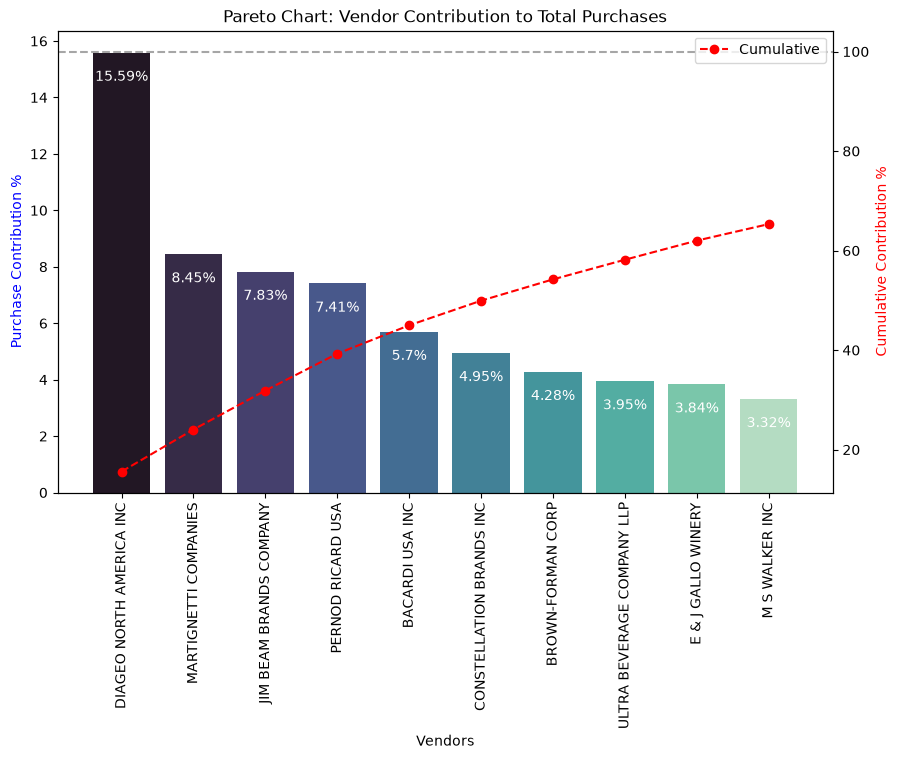

In [203]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

In [204]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.32 %


<h3 style="
    color:#111111;
    font-size:24px;
    font-weight:700;
    margin-top:25px;
    margin-bottom:15px;
">
 Top Vendors by Sales &amp; Purchase Contribution
</h3>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
The top 10 vendors contribute <b>65.32%</b> of total purchases,
while the remaining vendors contribute only <b>34.68%</b>.
This over-reliance on a few vendors may introduce risks such as
supply chain disruptions, indicating a need for diversification.
</p>

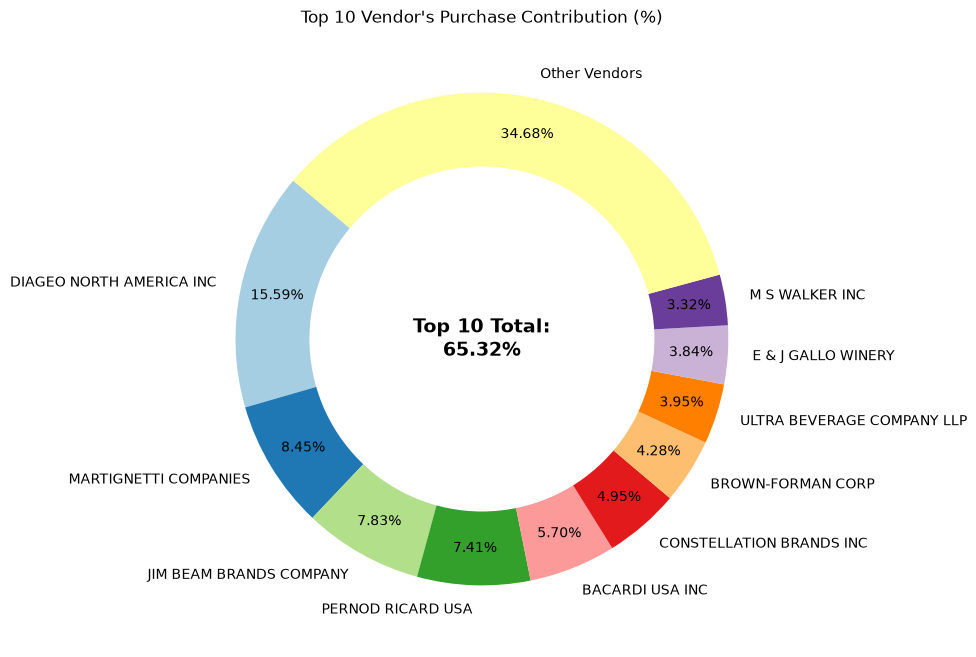

In [205]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.2f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

In [206]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [207]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice
0,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,115609.0,2680972.71,160247.0,4.819073e+06,561512.37,294438.66,144929.24,2.138101e+06,44.367466,1.386112,1.797509,23.19
1,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,101636.0,2669977.72,142049.0,5.101920e+06,672819.31,260999.20,68601.68,2.431942e+06,47.667192,1.397625,1.910847,26.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,136129.0,2482992.96,187140.0,4.538121e+06,461140.15,343854.07,123780.22,2.055128e+06,45.285875,1.374725,1.827682,18.24
3,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,95215.0,2084256.35,135838.0,4.223108e+06,545778.28,249587.83,257032.07,2.138851e+06,50.646383,1.426645,2.026194,21.89
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,119516.0,1932573.72,200412.0,4.475973e+06,420050.01,368242.80,257032.07,2.543399e+06,56.823382,1.676863,2.316068,16.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8905,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2.0,2.84,14.0,2.786000e+01,5.97,0.73,257032.07,2.502000e+01,89.806174,7.000000,9.809859,1.42
8906,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2.0,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,1.331000e+01,83.448276,2.500000,6.041667,1.32
8907,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6.0,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,6.332000e+01,96.436186,22.333333,28.059829,0.39
8908,3960,DIAGEO NORTH AMERICA INC,3775,Smirnoff Sorbet Pine/Coconut,0.73,0.99,50.0,1.0,0.73,120.0,1.188000e+02,46.53,6.20,257032.07,1.180700e+02,99.385522,120.000000,162.739726,0.73


In [208]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice,OrderSize
0,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,115609.0,2680972.71,160247.0,4.819073e+06,561512.37,294438.66,144929.24,2.138101e+06,44.367466,1.386112,1.797509,23.19,Large
1,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,101636.0,2669977.72,142049.0,5.101920e+06,672819.31,260999.20,68601.68,2.431942e+06,47.667192,1.397625,1.910847,26.27,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,136129.0,2482992.96,187140.0,4.538121e+06,461140.15,343854.07,123780.22,2.055128e+06,45.285875,1.374725,1.827682,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,95215.0,2084256.35,135838.0,4.223108e+06,545778.28,249587.83,257032.07,2.138851e+06,50.646383,1.426645,2.026194,21.89,Large
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,119516.0,1932573.72,200412.0,4.475973e+06,420050.01,368242.80,257032.07,2.543399e+06,56.823382,1.676863,2.316068,16.17,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8905,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2.0,2.84,14.0,2.786000e+01,5.97,0.73,257032.07,2.502000e+01,89.806174,7.000000,9.809859,1.42,Small
8906,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2.0,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,1.331000e+01,83.448276,2.500000,6.041667,1.32,Small
8907,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6.0,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,6.332000e+01,96.436186,22.333333,28.059829,0.39,Small
8908,3960,DIAGEO NORTH AMERICA INC,3775,Smirnoff Sorbet Pine/Coconut,0.73,0.99,50.0,1.0,0.73,120.0,1.188000e+02,46.53,6.20,257032.07,1.180700e+02,99.385522,120.000000,162.739726,0.73,Small


In [209]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,115609.0
1,Large,101636.0
2,Large,136129.0
3,Large,95215.0
4,Large,119516.0
...,...,...
8905,Small,2.0
8906,Small,2.0
8907,Small,6.0
8908,Small,1.0


<h3 style="
    color:#111111;
    font-size:24px;
    font-weight:700;
    margin-top:25px;
    margin-bottom:18px;
">
Impact of Bulk Purchasing on Cost Savings
</h3>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
Vendors buying in large quantities receive a
<b>70.41% lower unit cost ($10.75 per unit vs. higher unit costs in smaller orders).</b>
</p>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
Bulk pricing strategies encourage larger orders, increasing total sales
while maintaining profitability.
</p>

In [210]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,36.337092
Medium,16.147577
Large,10.757976


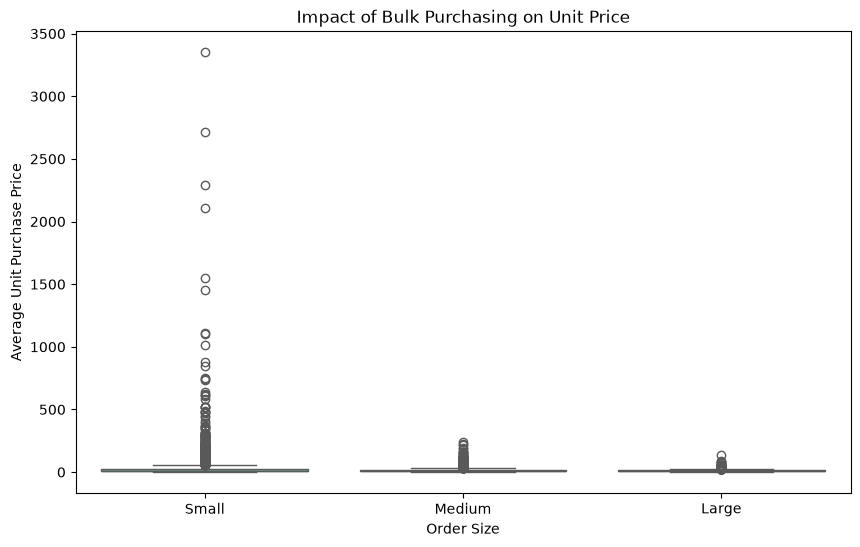

In [211]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

In [212]:
df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending = True).head(10)


,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.640000
GILMANTON WINERY & VINEYARD,0.651042
JEWELL TOWNE VINEYARDS,0.677419
HIGHLAND WINE MERCHANTS LLC,0.708333
Dunn Wine Brokers,0.742157
SURVILLE ENTERPRISES CORP,0.750000
STE MICHELLE WINE ESTATES,0.789459
DIAGEO CHATEAU ESTATE WINES,0.790680
AMERICAN SPIRITS EXCHANGE,0.791667


In [213]:
current_df = df[df["StockTurnover"] < 1].copy()

current_df["UnsoldInventoryValue"] = (
    (current_df["TotalPurchaseQuantity"] - current_df["TotalSalesQuantity"])
    * current_df["PurchasePrice"]
)

print("Total Unsold Capital:",
      format_dollars(current_df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 478.79K


In [214]:
current_df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,...,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice,OrderSize,UnsoldInventoryValue
8,3960,DIAGEO NORTH AMERICA INC,4260,Capt Morgan Original Barrel,16.66,21.99,1750.0,79074.0,1317372.84,79042.0,...,121065.25,145234.95,257032.07,318293.74,19.459573,0.999595,1.241612,16.66,Large,533.12
142,1128,BROWN-FORMAN CORP,1237,Jack Daniels Single Barrel,33.83,44.99,750.0,6740.0,228014.20,6658.0,...,179485.90,5246.55,68601.68,75984.22,24.994939,0.987834,1.333243,33.83,Large,2774.06
178,12546,JIM BEAM BRANDS COMPANY,273,Sauza Extra Gold Tequila,17.31,21.99,1750.0,10742.0,185944.02,10442.0,...,131726.72,19190.54,123880.97,49599.56,21.057488,0.972072,1.266745,17.31,Large,5193.00
196,12546,JIM BEAM BRANDS COMPANY,4199,Sauza Blanco Tequila,16.92,23.99,1750.0,9866.0,166932.72,9217.0,...,130690.44,16938.88,123880.97,41943.11,20.080404,0.934219,1.251258,16.92,Large,10981.08
440,1128,BROWN-FORMAN CORP,5297,Southern Comfort,10.76,13.99,750.0,8616.0,92708.16,8010.0,...,65972.66,6309.77,68601.68,23111.74,19.954895,0.929666,1.249296,10.76,Large,6520.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8522,1392,CONSTELLATION BRANDS INC,16916,R Mondavi Malbec Private Slt,5.15,7.99,750.0,12.0,61.80,10.0,...,34.96,1.12,79528.99,24.10,28.055879,0.833333,1.389968,5.15,Small,10.30
8523,3252,E & J GALLO WINERY,23296,Livingston Burgundy Calif,5.15,7.99,1500.0,12.0,61.80,10.0,...,63.92,2.22,61966.91,18.10,22.653317,0.833333,1.292880,5.15,Small,10.30
8562,8352,LUXCO INC,8629,Ezra Brooks Cinnamon Bourbon,11.02,13.99,1750.0,5.0,55.10,3.0,...,37.98,5.51,10261.60,1.87,3.282429,0.600000,1.033938,11.02,Small,22.04
8625,4425,MARTIGNETTI COMPANIES,11653,Mas Belles Eaux Les Cot Roug,6.57,9.99,750.0,7.0,45.99,3.0,...,16.99,0.34,144929.24,4.98,9.770453,0.428571,1.108284,6.57,Small,26.28


In [215]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice,OrderSize
0,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,115609.0,2680972.71,160247.0,4.819073e+06,561512.37,294438.66,144929.24,2.138101e+06,44.367466,1.386112,1.797509,23.19,Large
1,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,101636.0,2669977.72,142049.0,5.101920e+06,672819.31,260999.20,68601.68,2.431942e+06,47.667192,1.397625,1.910847,26.27,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,136129.0,2482992.96,187140.0,4.538121e+06,461140.15,343854.07,123780.22,2.055128e+06,45.285875,1.374725,1.827682,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,95215.0,2084256.35,135838.0,4.223108e+06,545778.28,249587.83,257032.07,2.138851e+06,50.646383,1.426645,2.026194,21.89,Large
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,119516.0,1932573.72,200412.0,4.475973e+06,420050.01,368242.80,257032.07,2.543399e+06,56.823382,1.676863,2.316068,16.17,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8905,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2.0,2.84,14.0,2.786000e+01,5.97,0.73,257032.07,2.502000e+01,89.806174,7.000000,9.809859,1.42,Small
8906,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2.0,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,1.331000e+01,83.448276,2.500000,6.041667,1.32,Small
8907,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6.0,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,6.332000e+01,96.436186,22.333333,28.059829,0.39,Small
8908,3960,DIAGEO NORTH AMERICA INC,3775,Smirnoff Sorbet Pine/Coconut,0.73,0.99,50.0,1.0,0.73,120.0,1.188000e+02,46.53,6.20,257032.07,1.180700e+02,99.385522,120.000000,162.739726,0.73,Small


In [216]:
print("Negative values:", (current_df['UnsoldInventoryValue'] < 0).sum())
print("Positive values:", (current_df['UnsoldInventoryValue'] > 0).sum())
print("Zero values:", (current_df['UnsoldInventoryValue'] == 0).sum())

Negative values: 0
Positive values: 875
Zero values: 0


In [218]:

print('Total Unsold Capital:', format_dollars(current_df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 478.79K


<h3 style="
    color:#111111;
    font-size:24px;
    font-weight:700;
    margin-top:25px;
    margin-bottom:18px;
">
4. Identifying Vendors with Low Inventory Turnover
</h3>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
Total Unsold Inventory Capital: <b>$478.79K</b>
</p>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
Slow-moving inventory increases storage costs, reduces cash flow
efficiency, and affects overall profitability.
</p>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
Identifying vendors with low inventory turnover enables better stock
management, minimizing financial strain.
</p>

In [219]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = current_df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
34,MARTIGNETTI COMPANIES,68.69K
41,PERFECTA WINES,53.49K
65,ULTRA BEVERAGE COMPANY LLP,49.67K
32,M S WALKER INC,47.61K
28,JIM BEAM BRANDS COMPANY,41.77K
4,BROWN-FORMAN CORP,30.16K
21,FABRIZIA SPIRITS LLC,14.12K
24,FREDERICK WILDMAN & SONS,12.75K
9,CONSTELLATION BRANDS INC,11.83K
18,Dunn Wine Brokers,8.50K


In [220]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio,UnitPurchasePrice,OrderSize
0,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,115609.0,2680972.71,160247.0,4.819073e+06,561512.37,294438.66,144929.24,2.138101e+06,44.367466,1.386112,1.797509,23.19,Large
1,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,101636.0,2669977.72,142049.0,5.101920e+06,672819.31,260999.20,68601.68,2.431942e+06,47.667192,1.397625,1.910847,26.27,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,136129.0,2482992.96,187140.0,4.538121e+06,461140.15,343854.07,123780.22,2.055128e+06,45.285875,1.374725,1.827682,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,95215.0,2084256.35,135838.0,4.223108e+06,545778.28,249587.83,257032.07,2.138851e+06,50.646383,1.426645,2.026194,21.89,Large
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,119516.0,1932573.72,200412.0,4.475973e+06,420050.01,368242.80,257032.07,2.543399e+06,56.823382,1.676863,2.316068,16.17,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8905,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2.0,2.84,14.0,2.786000e+01,5.97,0.73,257032.07,2.502000e+01,89.806174,7.000000,9.809859,1.42,Small
8906,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2.0,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,1.331000e+01,83.448276,2.500000,6.041667,1.32,Small
8907,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6.0,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,6.332000e+01,96.436186,22.333333,28.059829,0.39,Small
8908,3960,DIAGEO NORTH AMERICA INC,3775,Smirnoff Sorbet Pine/Coconut,0.73,0.99,50.0,1.0,0.73,120.0,1.188000e+02,46.53,6.20,257032.07,1.180700e+02,99.385522,120.000000,162.739726,0.73,Small


In [221]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[
    df["TotalSalesDollars"] >= top_threshold
]["ProfitMargin"].dropna()

low_vendors = df[
    df["TotalSalesDollars"] <= low_threshold
]["ProfitMargin"].dropna()    

In [222]:
top_vendors

0       44.367466
1       47.667192
2       45.285875
3       50.646383
4       56.823382
          ...    
7914    99.721130
8062    99.945514
8223    99.778252
8641    99.981950
8893    99.994466
Name: ProfitMargin, Length: 2228, dtype: float64

In [223]:
low_vendors

5592     4.111764
5689     7.239599
5692     1.323192
5723    15.862303
5733     5.874758
          ...    
8905    89.806174
8906    83.448276
8907    96.436186
8908    99.385522
8909    99.166079
Name: ProfitMargin, Length: 2228, dtype: float64

In [224]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

<h3 style="
    color:#111111;
    font-size:24px;
    font-weight:700;
    margin-top:25px;
    margin-bottom:18px;
">
5. Profit Margin Comparison: High vs. Low-Performing Vendors
</h3>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
Top Vendors' Profit Margin (95% CI): (52.01%, 52.95%), Mean: 52.48%
</p>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
Low Vendors' Profit Margin (95% CI): (48.66%, 50.67%), Mean: 49.66%
</p>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-bottom:20px;
">
Low-performing vendors maintain higher margins but struggle with sales
volumes, indicating potential pricing inefficiencies or market reach issues.
</p>

<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-top:25px;
">
<p style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-top:10px;
    margin-bottom:15px;
">
<b>Actionable Insights:</b>
</p>

<ul style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-left:70px;
">

<li>
<b>Top-performing vendors:</b>
Optimize profitability by adjusting pricing,
reducing operational costs, or offering bundled promotions.
</li>

</ul>
<ul style="
    font-size:18px;
    line-height:1.6;
    color:#222222;
    margin-left:70px;
">

<li>
<b>Low-performing vendors:</b>
Improve marketing efforts, optimize
pricing strategies, and enhance distribution networks.
</li>

</ul>

Top Vendors 95% CI: (52.01, 52.95), Mean: 52.48
Low Vendors 95% CI: (48.66, 50.67), Mean: 49.66


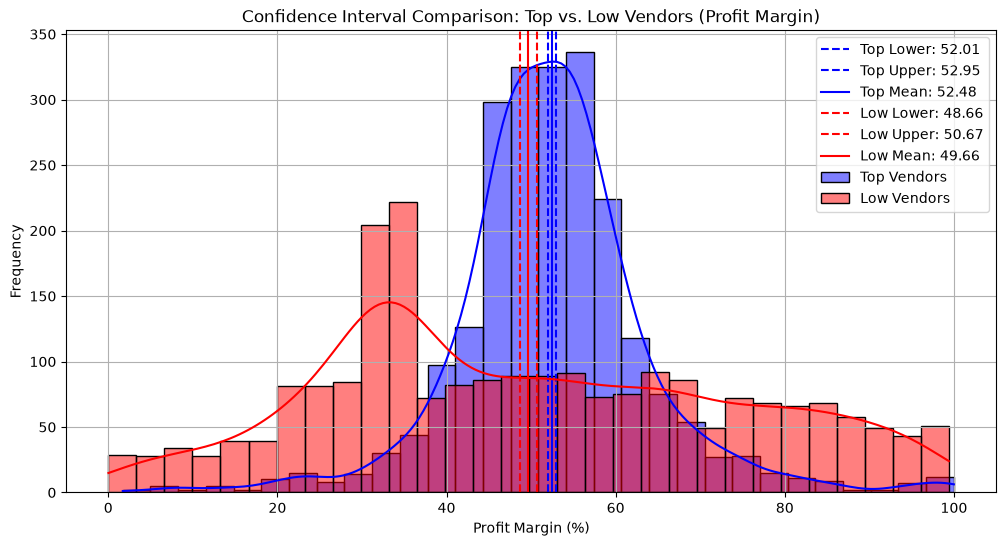

In [225]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()